In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("student_performance_updated_1000.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 12)


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [3]:
def grade_category(grade):
    if grade < 50:
        return "Fail"
    elif grade < 60:
        return "Pass"
    elif grade < 70:
        return "Average"
    elif grade < 80:
        return "Good"
    else:
        return "Excellent"


df["GradeCategory"] = df["FinalGrade"].apply(grade_category)

df[["FinalGrade", "GradeCategory"]].head(10)

,FinalGrade,GradeCategory
0,80.0,Excellent
1,87.0,Excellent
2,68.0,Average
3,92.0,Excellent
4,85.0,Excellent
5,NaN,Excellent
6,62.0,Average
7,78.0,Good
8,72.0,Good
9,88.0,Excellent


In [4]:
print(df["GradeCategory"].value_counts())

GradeCategory
Excellent    603
Good         214
Average      183
Name: count, dtype: int64


In [5]:
target = "GradeCategory"

features = [
    col for col in df.columns
    if col not in [
        "FinalGrade",
        "GradeCategory",
        "StudentID",
        "Name"
    ]
]

X = df[features]
y = df[target]

print("Features:")
print(features)

print("\nTarget:")
print(target)

Features:
['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']

Target:
GradeCategory


In [6]:
categorical_columns = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'Study Hours', 'Attendance (%)']

Categorical columns:
['Gender', 'ParentalSupport', 'Online Classes Taken']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6036\1392239844.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 9)
Testing data: (200, 9)


In [8]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        SimpleImputer(strategy="median"),
        numerical_columns
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_columns
    )
])

In [9]:
decision_tree_classifier = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        )
    )
])

In [10]:
decision_tree_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [11]:
y_pred = decision_tree_classifier.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
['Excellent' 'Excellent' 'Excellent' 'Excellent' 'Good' 'Good' 'Excellent'
 'Excellent' 'Excellent' 'Excellent']


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Classification Accuracy:",
      round(accuracy * 100, 2), "%")

Decision Tree Classification Accuracy: 57.0 %


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Average       0.20      0.06      0.09        36
   Excellent       0.62      0.89      0.73       121
        Good       0.24      0.09      0.13        43

    accuracy                           0.57       200
   macro avg       0.35      0.35      0.32       200
weighted avg       0.46      0.57      0.49       200



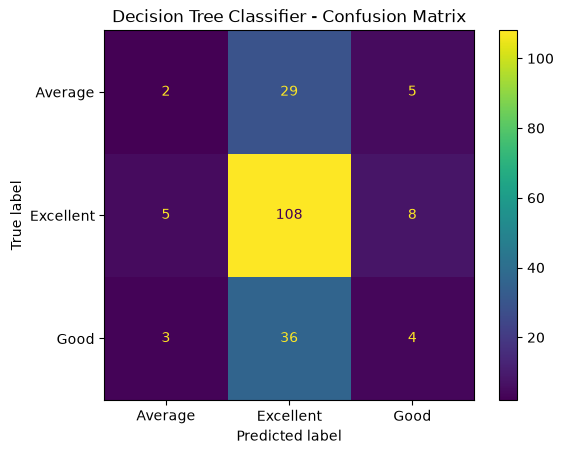

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=decision_tree_classifier.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=decision_tree_classifier.classes_
)

disp.plot()
plt.title("Decision Tree Classifier - Confusion Matrix")
plt.show()